In [1]:
import xarray as xr
import numpy as np
import glob
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

data_dir = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010"
)

file_pattern = (
    f"{data_dir}/o2-inventories_Omon_NorESM2-LM_esm-up2p0_"
    "r1i1p1f1_gr_*.nc"
)

all_vars = [
    "o2_inv_mld",
    "o2_inv_100m",
    "o2_inv_200m",
    "o2_inv_300m",
    "o2_inv_500m",
    "o2_inv_700m",
    "o2_inv_1000m",
    "o2_inv_1500m",
    "o2_inv_2000m",
    "o2_inv_total",
]

# ============================================================
# Trend function
# ============================================================

def linear_trend_1d(values, years):
    """
    Linear trend of values against decimal years.
    Return trend per century.
    """
    valid = np.isfinite(values) & np.isfinite(years)

    if valid.sum() < 24:
        return np.nan

    x = years[valid]
    y = values[valid]

    slope = np.polyfit(x, y, 1)[0]

    return slope * 100.0  # per century


# ============================================================
# Open data
# ============================================================

files = sorted(glob.glob(file_pattern))
print(f"Found {len(files)} inventory files")

if len(files) == 0:
    raise FileNotFoundError("No inventory files found. Please check file_pattern.")

ds = xr.open_mfdataset(
    files,
    combine="by_coords",
    use_cftime=True,
    data_vars="minimal",
    coords="minimal",
    compat="override",
    chunks={"time": -1}
)

# Decimal year
decimal_year = (
    ds.time.dt.year
    + (ds.time.dt.month - 0.5) / 12.0
).astype(float)

# ============================================================
# Compute trend maps
# ============================================================

trend_maps = {}

for var in all_vars:

    if var not in ds.variables:
        print(f"{var}: not found, skipped")
        continue

    print(f"Processing {var}")

    da = ds[var]

    trend = xr.apply_ufunc(
        linear_trend_1d,
        da,
        decimal_year,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        dask_gufunc_kwargs={"allow_rechunk": True},
        output_dtypes=[float],
    )

    print("  Computing trend...")
    trend_maps[var] = trend.compute()

print("Done.")

Found 23 inventory files
Processing o2_inv_mld
  Computing trend...
Processing o2_inv_100m
  Computing trend...
Processing o2_inv_200m
  Computing trend...
Processing o2_inv_300m
  Computing trend...
Processing o2_inv_500m
  Computing trend...
Processing o2_inv_700m
  Computing trend...
Processing o2_inv_1000m
  Computing trend...
Processing o2_inv_1500m
  Computing trend...
Processing o2_inv_2000m
  Computing trend...
Processing o2_inv_total
  Computing trend...
Done.


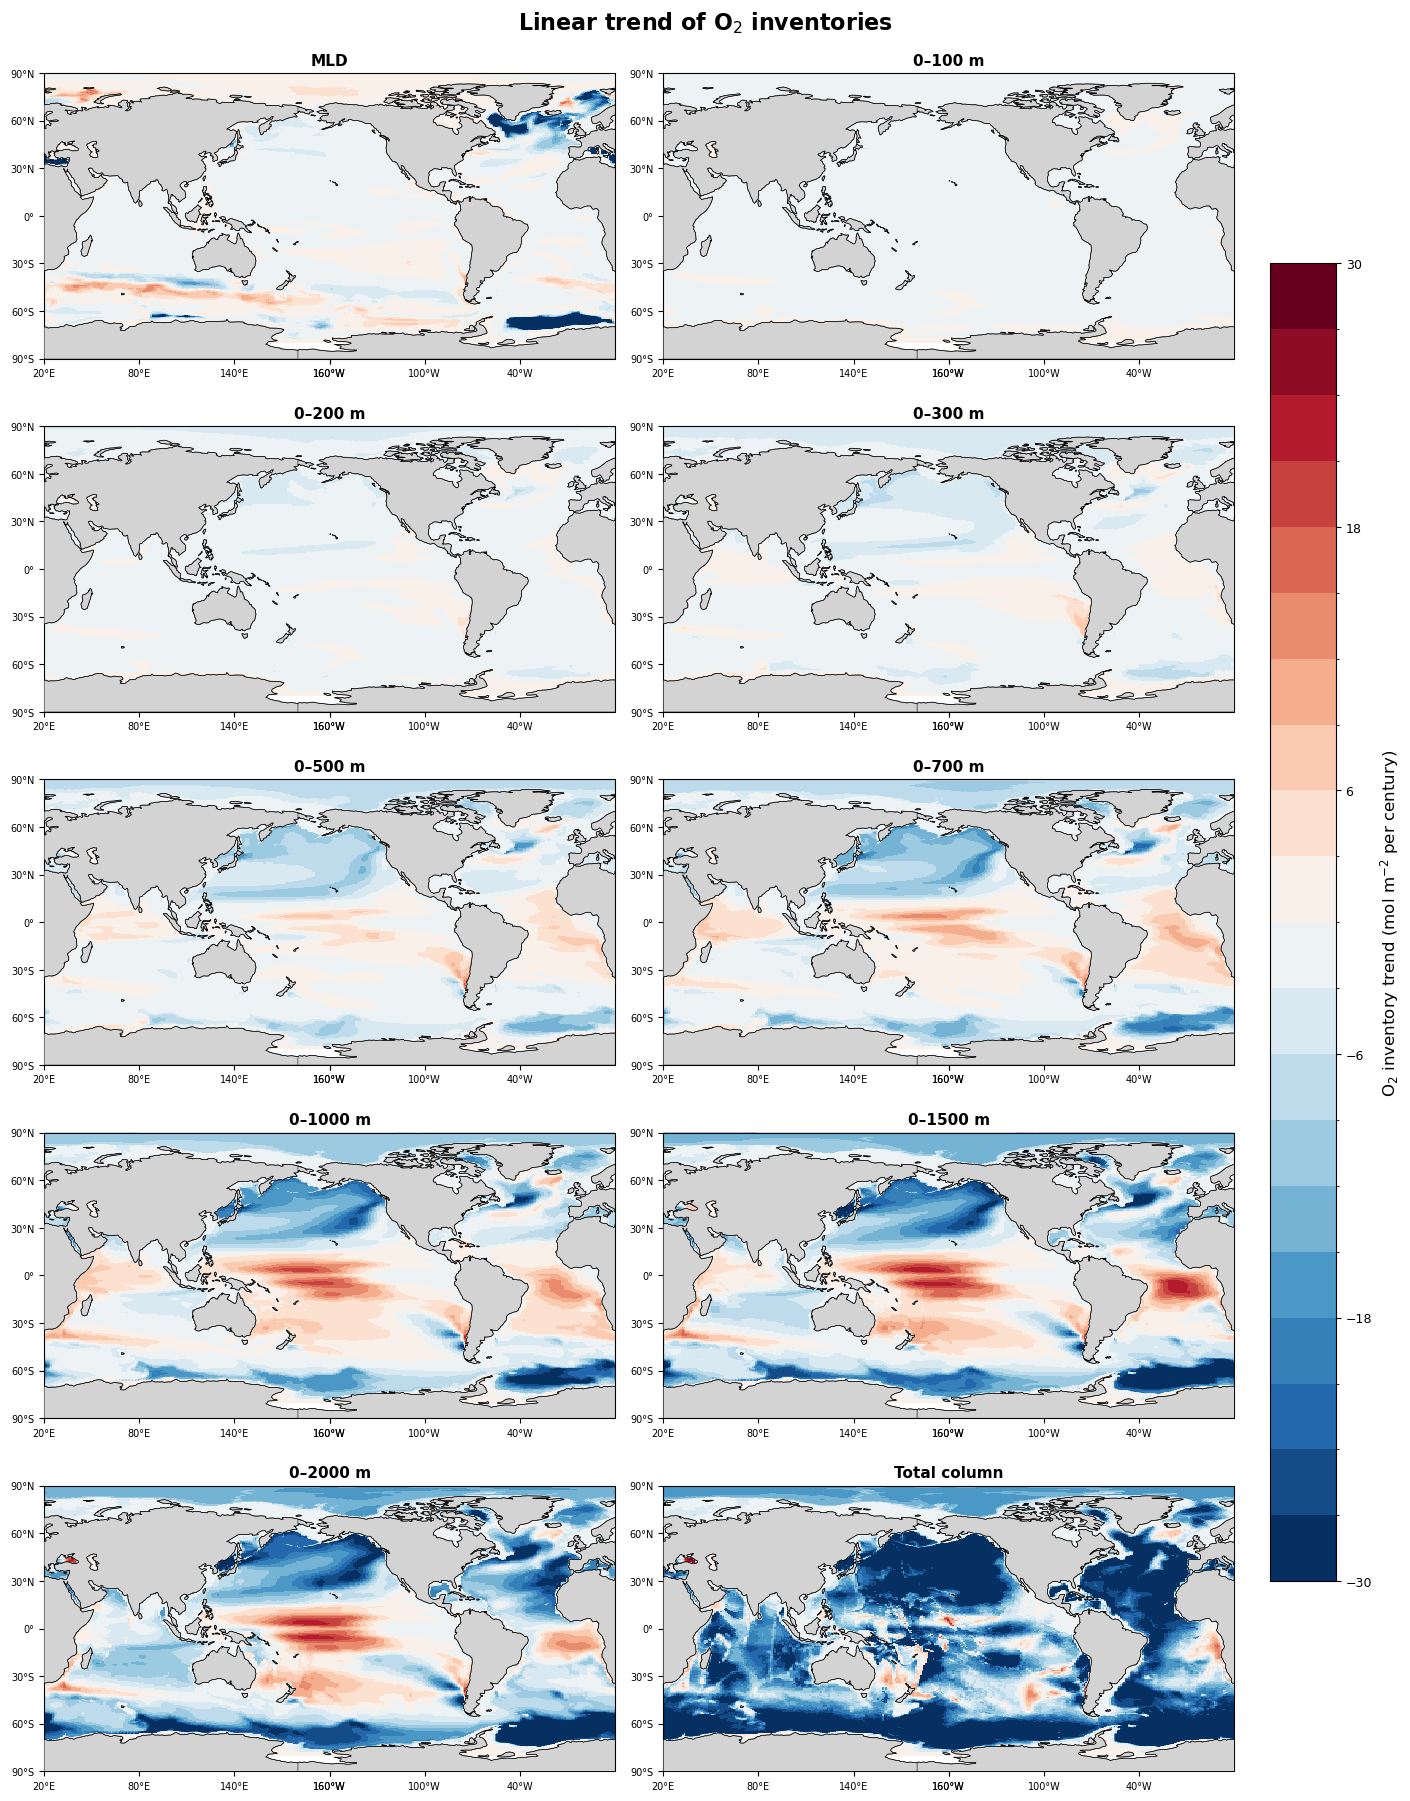

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import warnings

warnings.filterwarnings("ignore", message="The colormap's 'bad' has been set")

# ============================================================
# Symmetric color range around zero
# ============================================================

all_values = np.concatenate([
    da.values[np.isfinite(da.values)]
    for da in trend_maps.values()
])

vmax = np.nanpercentile(np.abs(all_values), 98)
vmax = np.ceil(vmax / 10) * 10
vmin = -vmax

levels = np.linspace(vmin, vmax, 21)

cmap = plt.get_cmap("RdBu_r", len(levels) - 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(levels, cmap.N)

# ============================================================
# Pretty variable labels
# ============================================================

label_map = {
    "o2_inv_mld": "MLD",
    "o2_inv_100m": "0–100 m",
    "o2_inv_200m": "0–200 m",
    "o2_inv_300m": "0–300 m",
    "o2_inv_500m": "0–500 m",
    "o2_inv_700m": "0–700 m",
    "o2_inv_1000m": "0–1000 m",
    "o2_inv_1500m": "0–1500 m",
    "o2_inv_2000m": "0–2000 m",
    "o2_inv_total": "Total column",
}

# ============================================================
# Map projection
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    5,
    2,
    figsize=(14, 18),
    subplot_kw={"projection": map_crs},
    constrained_layout=True
)

axes = axes.flatten()

for ax, (var, trend) in zip(axes, trend_maps.items()):

    pcm = trend.plot(
        ax=ax,
        x="longitude",
        y="latitude",
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        add_colorbar=False
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3,
        zorder=10
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.5,
        zorder=11
    )

    ax.set_global()

    ax.set_xticks(np.arange(-160, 201, 60), crs=data_crs)
    ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=7)

    ax.set_title(
        label_map.get(var, var),
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("")

# Hide unused axes if any
for ax in axes[len(trend_maps):]:
    ax.set_visible(False)

# ============================================================
# Colorbar
# ============================================================

cbar = fig.colorbar(
    pcm,
    ax=axes,
    boundaries=levels,
    ticks=levels[::4],
    spacing="proportional",
    shrink=0.75,
    pad=0.03
)

cbar.set_label(
    "O$_2$ inventory trend (mol m$^{-2}$ per century)",
    fontsize=12
)

cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    "Linear trend of O$_2$ inventories",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    "trend_O2_inventory_mol_m2_per_century_panels_center200E.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Computing CO2...
CO2: 23 files found
Computing O2 inventory global means...
Processing o2_inv_mld
Processing o2_inv_100m
Processing o2_inv_200m
Processing o2_inv_300m
Processing o2_inv_500m
Processing o2_inv_700m
Processing o2_inv_1000m
Processing o2_inv_1500m
Processing o2_inv_2000m
Processing o2_inv_total
Available inventory series: ['o2_inv_mld', 'o2_inv_100m', 'o2_inv_200m', 'o2_inv_300m', 'o2_inv_500m', 'o2_inv_700m', 'o2_inv_1000m', 'o2_inv_1500m', 'o2_inv_2000m', 'o2_inv_total']


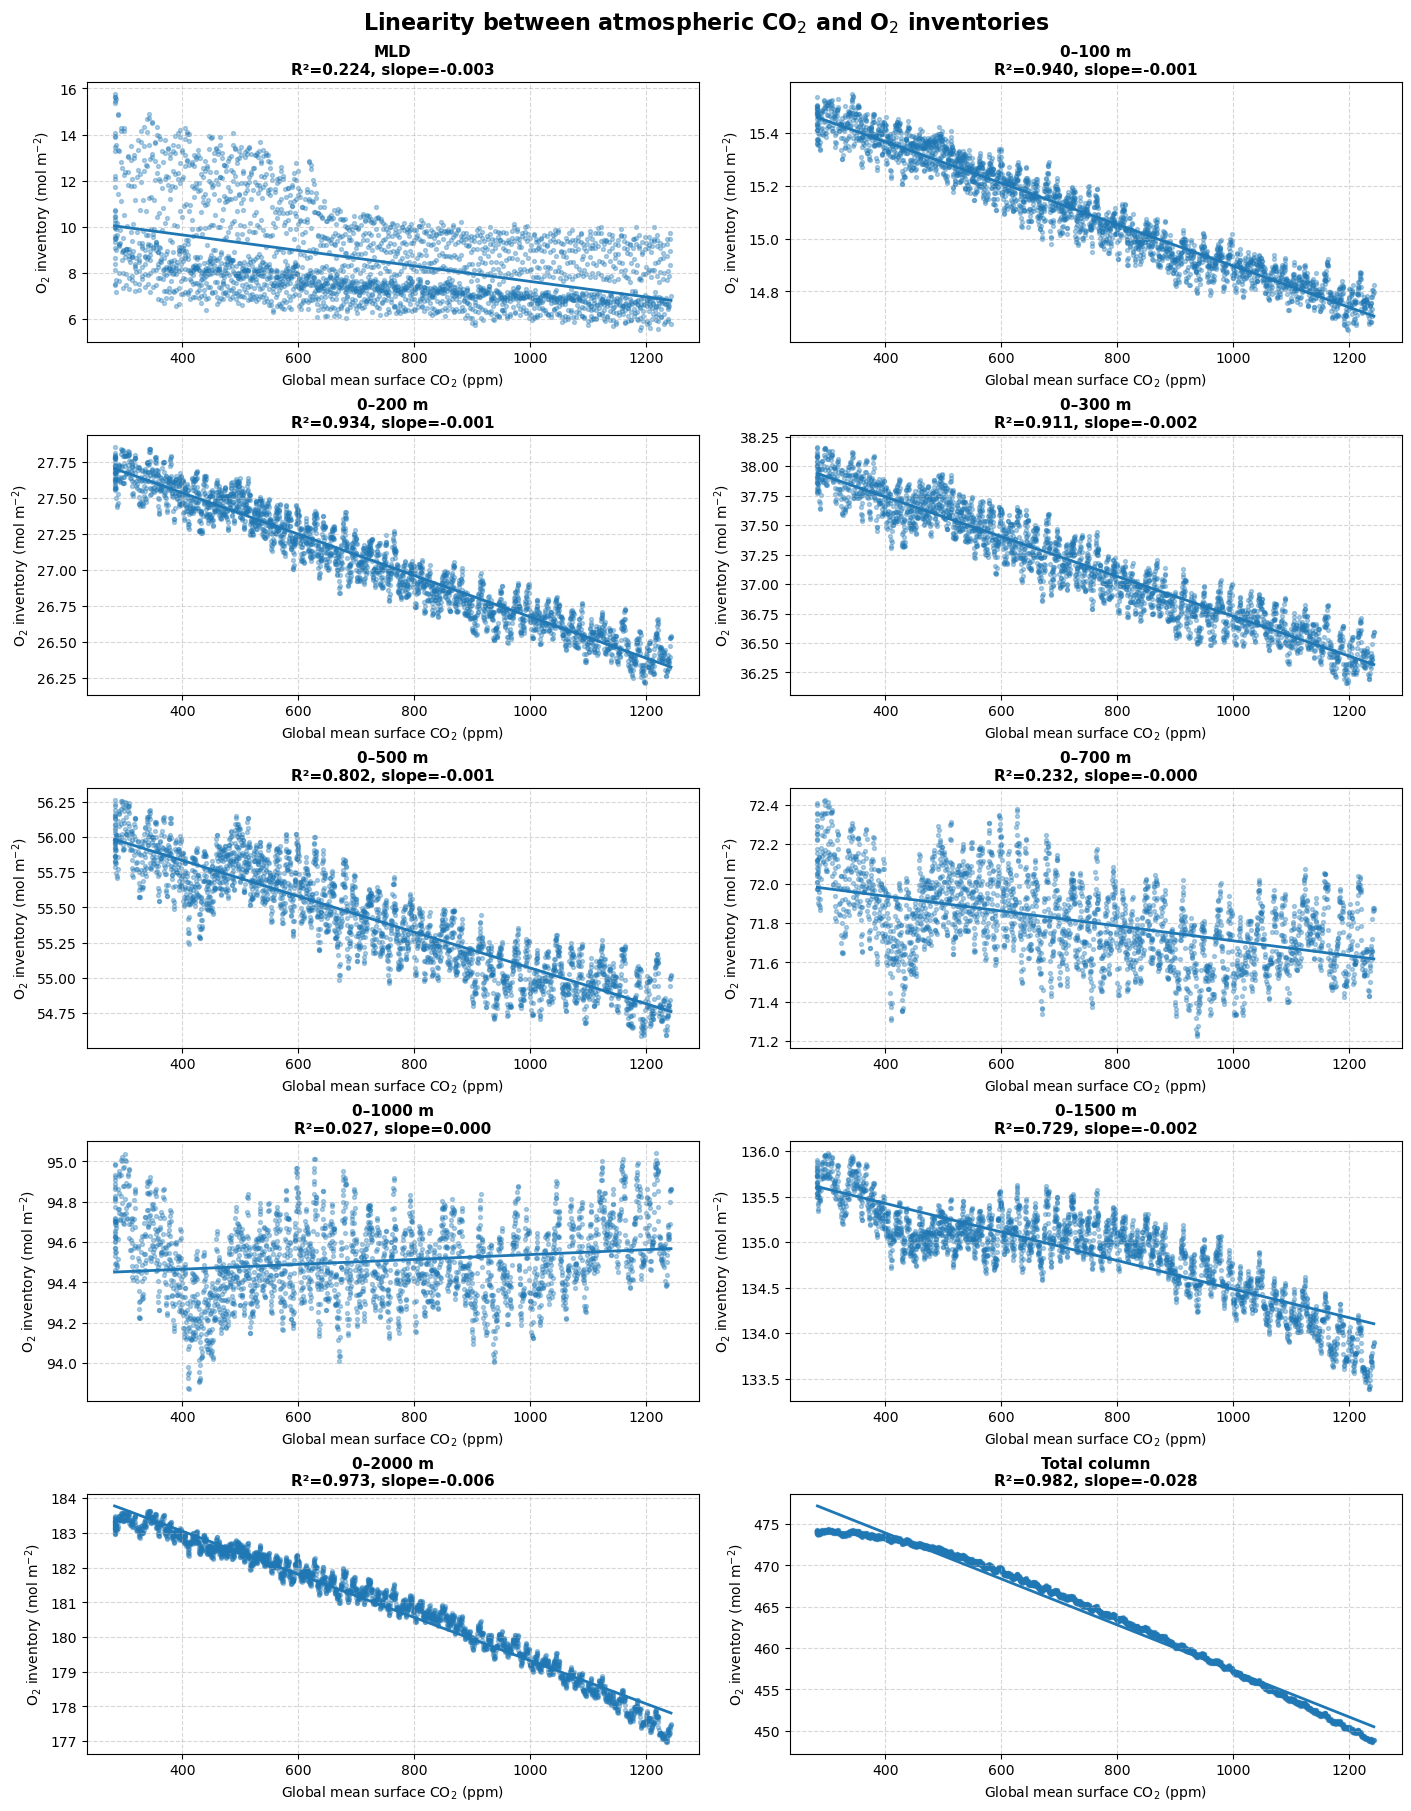

----------------------------------------------------------------------------------------------------
O2 inventory = slope × CO2(ppm) + intercept
----------------------------------------------------------------------------------------------------
MLD          | n= 2700 | slope=-0.003355 mol m-2 ppm-1 | R2=0.2235 | p=2.00e-150
0–100 m      | n= 2700 | slope=-0.000783 mol m-2 ppm-1 | R2=0.9400 | p=0.00e+00
0–200 m      | n= 2700 | slope=-0.001435 mol m-2 ppm-1 | R2=0.9336 | p=0.00e+00
0–300 m      | n= 2700 | slope=-0.001689 mol m-2 ppm-1 | R2=0.9112 | p=0.00e+00
0–500 m      | n= 2700 | slope=-0.001270 mol m-2 ppm-1 | R2=0.8023 | p=0.00e+00
0–700 m      | n= 2700 | slope=-0.000378 mol m-2 ppm-1 | R2=0.2315 | p=1.58e-156
0–1000 m     | n= 2700 | slope=0.000121 mol m-2 ppm-1 | R2=0.0267 | p=1.26e-17
0–1500 m     | n= 2700 | slope=-0.001568 mol m-2 ppm-1 | R2=0.7287 | p=0.00e+00
0–2000 m     | n= 2700 | slope=-0.006216 mol m-2 ppm-1 | R2=0.9726 | p=0.00e+00
Total column | n= 2700 | slope=-0

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import warnings
from scipy.stats import linregress

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

BASE_DIR = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010"
)

CO2_PATTERN = (
    "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
    "co2_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc"
)

INV_PATTERN = (
    f"{BASE_DIR}/o2-inventories_Omon_NorESM2-LM_esm-up2p0_"
    "r1i1p1f1_gr_*.nc"
)

INV_VARS = [
    "o2_inv_mld",
    "o2_inv_100m",
    "o2_inv_200m",
    "o2_inv_300m",
    "o2_inv_500m",
    "o2_inv_700m",
    "o2_inv_1000m",
    "o2_inv_1500m",
    "o2_inv_2000m",
    "o2_inv_total",
]

LABEL_MAP = {
    "o2_inv_mld": "MLD",
    "o2_inv_100m": "0–100 m",
    "o2_inv_200m": "0–200 m",
    "o2_inv_300m": "0–300 m",
    "o2_inv_500m": "0–500 m",
    "o2_inv_700m": "0–700 m",
    "o2_inv_1000m": "0–1000 m",
    "o2_inv_1500m": "0–1500 m",
    "o2_inv_2000m": "0–2000 m",
    "o2_inv_total": "Total column",
}

# ============================================================
# CO2 global mean
# ============================================================

def compute_global_mean_co2_ppm(file_pattern):

    files = sorted(glob.glob(file_pattern))
    print(f"CO2: {len(files)} files found")

    if len(files) == 0:
        raise FileNotFoundError("No CO2 files found.")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    co2 = ds["co2"]

    if "plev" in co2.dims:
        co2 = co2.isel(plev=-1, drop=True)

    weights = np.cos(np.deg2rad(ds["lat"])).fillna(0)

    co2_gm = co2.weighted(weights).mean(
        dim=["lat", "lon"],
        skipna=True
    )

    co2_ppm = (co2_gm * 1e6).compute()
    co2_ppm.name = "CO2_ppm"

    ds.close()

    return co2_ppm

# ============================================================
# O2 inventory global mean
# ============================================================

def compute_global_mean_inventory(file_pattern, varname):

    files = sorted(glob.glob(file_pattern))

    if len(files) == 0:
        raise FileNotFoundError("No O2 inventory files found.")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    if varname not in ds.variables:
        ds.close()
        print(f"{varname}: not found")
        return None

    da = ds[varname]

    # Area weights
    lat = ds["latitude"].where(np.abs(ds["latitude"]) <= 90)
    weights = np.cos(np.deg2rad(lat))

    ocean_mask = da.isel(time=0).notnull()
    weights = weights.where(ocean_mask).fillna(0)

    inv_gm = da.weighted(weights).mean(
        dim=["j", "i"],
        skipna=True
    ).compute()

    inv_gm.name = varname

    ds.close()

    return inv_gm

# ============================================================
# Compute series
# ============================================================

print("Computing CO2...")
co2_ppm = compute_global_mean_co2_ppm(CO2_PATTERN)

print("Computing O2 inventory global means...")
inv_series = {}

for var in INV_VARS:
    print(f"Processing {var}")
    da = compute_global_mean_inventory(INV_PATTERN, var)

    if da is not None:
        inv_series[var] = da

print("Available inventory series:", list(inv_series.keys()))

# ============================================================
# Regression: inventory vs CO2
# ============================================================

fit_results = {}

fig, axes = plt.subplots(
    5,
    2,
    figsize=(14, 18),
    constrained_layout=True
)

axes = axes.flatten()

for ax, (var, inv_da) in zip(axes, inv_series.items()):

    co2_aligned, inv_aligned = xr.align(
        co2_ppm,
        inv_da,
        join="inner"
    )

    x = co2_aligned.values
    y = inv_aligned.values

    valid = np.isfinite(x) & np.isfinite(y)

    x = x[valid]
    y = y[valid]

    reg = linregress(x, y)

    y_fit = reg.slope * x + reg.intercept
    r2 = reg.rvalue ** 2

    fit_results[var] = {
        "slope": reg.slope,
        "intercept": reg.intercept,
        "r2": r2,
        "pvalue": reg.pvalue,
        "stderr": reg.stderr,
        "n": len(x),
    }

    idx = np.argsort(x)

    ax.scatter(
        x,
        y,
        s=8,
        alpha=0.35
    )

    ax.plot(
        x[idx],
        y_fit[idx],
        linewidth=2
    )

    ax.set_title(
        f"{LABEL_MAP.get(var, var)}\n"
        f"R²={r2:.3f}, slope={reg.slope:.3f}",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel("Global mean surface CO$_2$ (ppm)")
    ax.set_ylabel("O$_2$ inventory (mol m$^{-2}$)")
    ax.grid(True, linestyle="--", alpha=0.5)

# Hide unused axes if any
for ax in axes[len(inv_series):]:
    ax.set_visible(False)

fig.suptitle(
    "Linearity between atmospheric CO$_2$ and O$_2$ inventories",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    "linear_relationship_CO2_vs_O2_inventories.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# Summary
# ============================================================

print("-" * 100)
print("O2 inventory = slope × CO2(ppm) + intercept")
print("-" * 100)

for var, res in fit_results.items():

    print(
        f"{LABEL_MAP.get(var, var):12s} | "
        f"n={res['n']:5d} | "
        f"slope={res['slope']:.6f} mol m-2 ppm-1 | "
        f"R2={res['r2']:.4f} | "
        f"p={res['pvalue']:.2e}"
    )

In [5]:
import xarray as xr
import numpy as np
import glob
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

# ============================================================
# Settings
# ============================================================

CO2_PATTERN = (
    "/nird/datalake/NS2980K/projects/TipESM/cmor/esm-up2p0/v20251010/"
    "co2_Amon_NorESM2-LM_esm-up2p0_r1i1p1f1_gn_*.nc"
)

INV_PATTERN = (
    "/nird/datalake/NS2980K/users/yongyub/O2_linearlity/"
    "TipESM/cmor/esm-up2p0/v20251010/"
    "o2-inventories_Omon_NorESM2-LM_esm-up2p0_r1i1p1f1_gr_*.nc"
)

INV_VARS = [
    "o2_inv_mld",
    "o2_inv_100m",
    "o2_inv_200m",
    "o2_inv_300m",
    "o2_inv_500m",
    "o2_inv_700m",
    "o2_inv_1000m",
    "o2_inv_1500m",
    "o2_inv_2000m",
    "o2_inv_total",
]

# ============================================================
# Functions
# ============================================================

def compute_global_mean_co2_ppm(file_pattern):
    files = sorted(glob.glob(file_pattern))
    print(f"CO2 files: {len(files)}")

    if len(files) == 0:
        raise FileNotFoundError("No CO2 files found.")

    ds = xr.open_mfdataset(
        files,
        combine="by_coords",
        use_cftime=True,
        data_vars="minimal",
        coords="minimal",
        compat="override"
    )

    co2 = ds["co2"]

    if "plev" in co2.dims:
        co2 = co2.isel(plev=-1, drop=True)

    weights = np.cos(np.deg2rad(ds["lat"])).fillna(0)

    co2_ppm = (
        co2.weighted(weights)
        .mean(dim=["lat", "lon"], skipna=True)
        * 1e6
    ).compute()

    co2_ppm.name = "co2_ppm"

    ds.close()

    return co2_ppm


def r2_1d(x, y):
    valid = np.isfinite(x) & np.isfinite(y)

    if valid.sum() < 24:
        return np.nan

    xx = x[valid]
    yy = y[valid]

    if np.nanstd(xx) == 0 or np.nanstd(yy) == 0:
        return np.nan

    r = np.corrcoef(xx, yy)[0, 1]

    return r ** 2

# ============================================================
# Load CO2
# ============================================================

print("Computing CO2...")
co2_ppm = compute_global_mean_co2_ppm(CO2_PATTERN)

co2_ppm = co2_ppm.chunk({"time": -1})

# ============================================================
# Load inventory files
# ============================================================

inv_files = sorted(glob.glob(INV_PATTERN))
print(f"Inventory files: {len(inv_files)}")

if len(inv_files) == 0:
    raise FileNotFoundError("No O2 inventory files found.")

ds_inv = xr.open_mfdataset(
    inv_files,
    combine="by_coords",
    use_cftime=True,
    data_vars="minimal",
    coords="minimal",
    compat="override",
    chunks={"time": -1}
)

# ============================================================
# Compute grid-point R2 maps
# ============================================================

r2_maps_inv = {}

for var in INV_VARS:

    if var not in ds_inv:
        print(f"Skipping missing variable: {var}")
        continue

    print(f"Computing R2 map: {var}")

    inv = ds_inv[var]

    co2_aligned, inv_aligned = xr.align(
        co2_ppm,
        inv,
        join="inner"
    )

    co2_aligned = co2_aligned.chunk({"time": -1})
    inv_aligned = inv_aligned.chunk({"time": -1})

    r2_map = xr.apply_ufunc(
        r2_1d,
        co2_aligned,
        inv_aligned,
        input_core_dims=[["time"], ["time"]],
        output_core_dims=[[]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

    r2_map = r2_map.compute()
    r2_map.name = f"r2_{var}_vs_co2"

    r2_map = r2_map.assign_coords(
        latitude=ds_inv["latitude"],
        longitude=ds_inv["longitude"]
    )

    r2_maps_inv[var] = r2_map

print("Done.")
print(f"Computed R2 maps: {list(r2_maps_inv.keys())}")

Computing CO2...
CO2 files: 23
Inventory files: 23
Computing R2 map: o2_inv_mld
Computing R2 map: o2_inv_100m
Computing R2 map: o2_inv_200m
Computing R2 map: o2_inv_300m
Computing R2 map: o2_inv_500m
Computing R2 map: o2_inv_700m
Computing R2 map: o2_inv_1000m
Computing R2 map: o2_inv_1500m
Computing R2 map: o2_inv_2000m
Computing R2 map: o2_inv_total
Done.
Computed R2 maps: ['o2_inv_mld', 'o2_inv_100m', 'o2_inv_200m', 'o2_inv_300m', 'o2_inv_500m', 'o2_inv_700m', 'o2_inv_1000m', 'o2_inv_1500m', 'o2_inv_2000m', 'o2_inv_total']


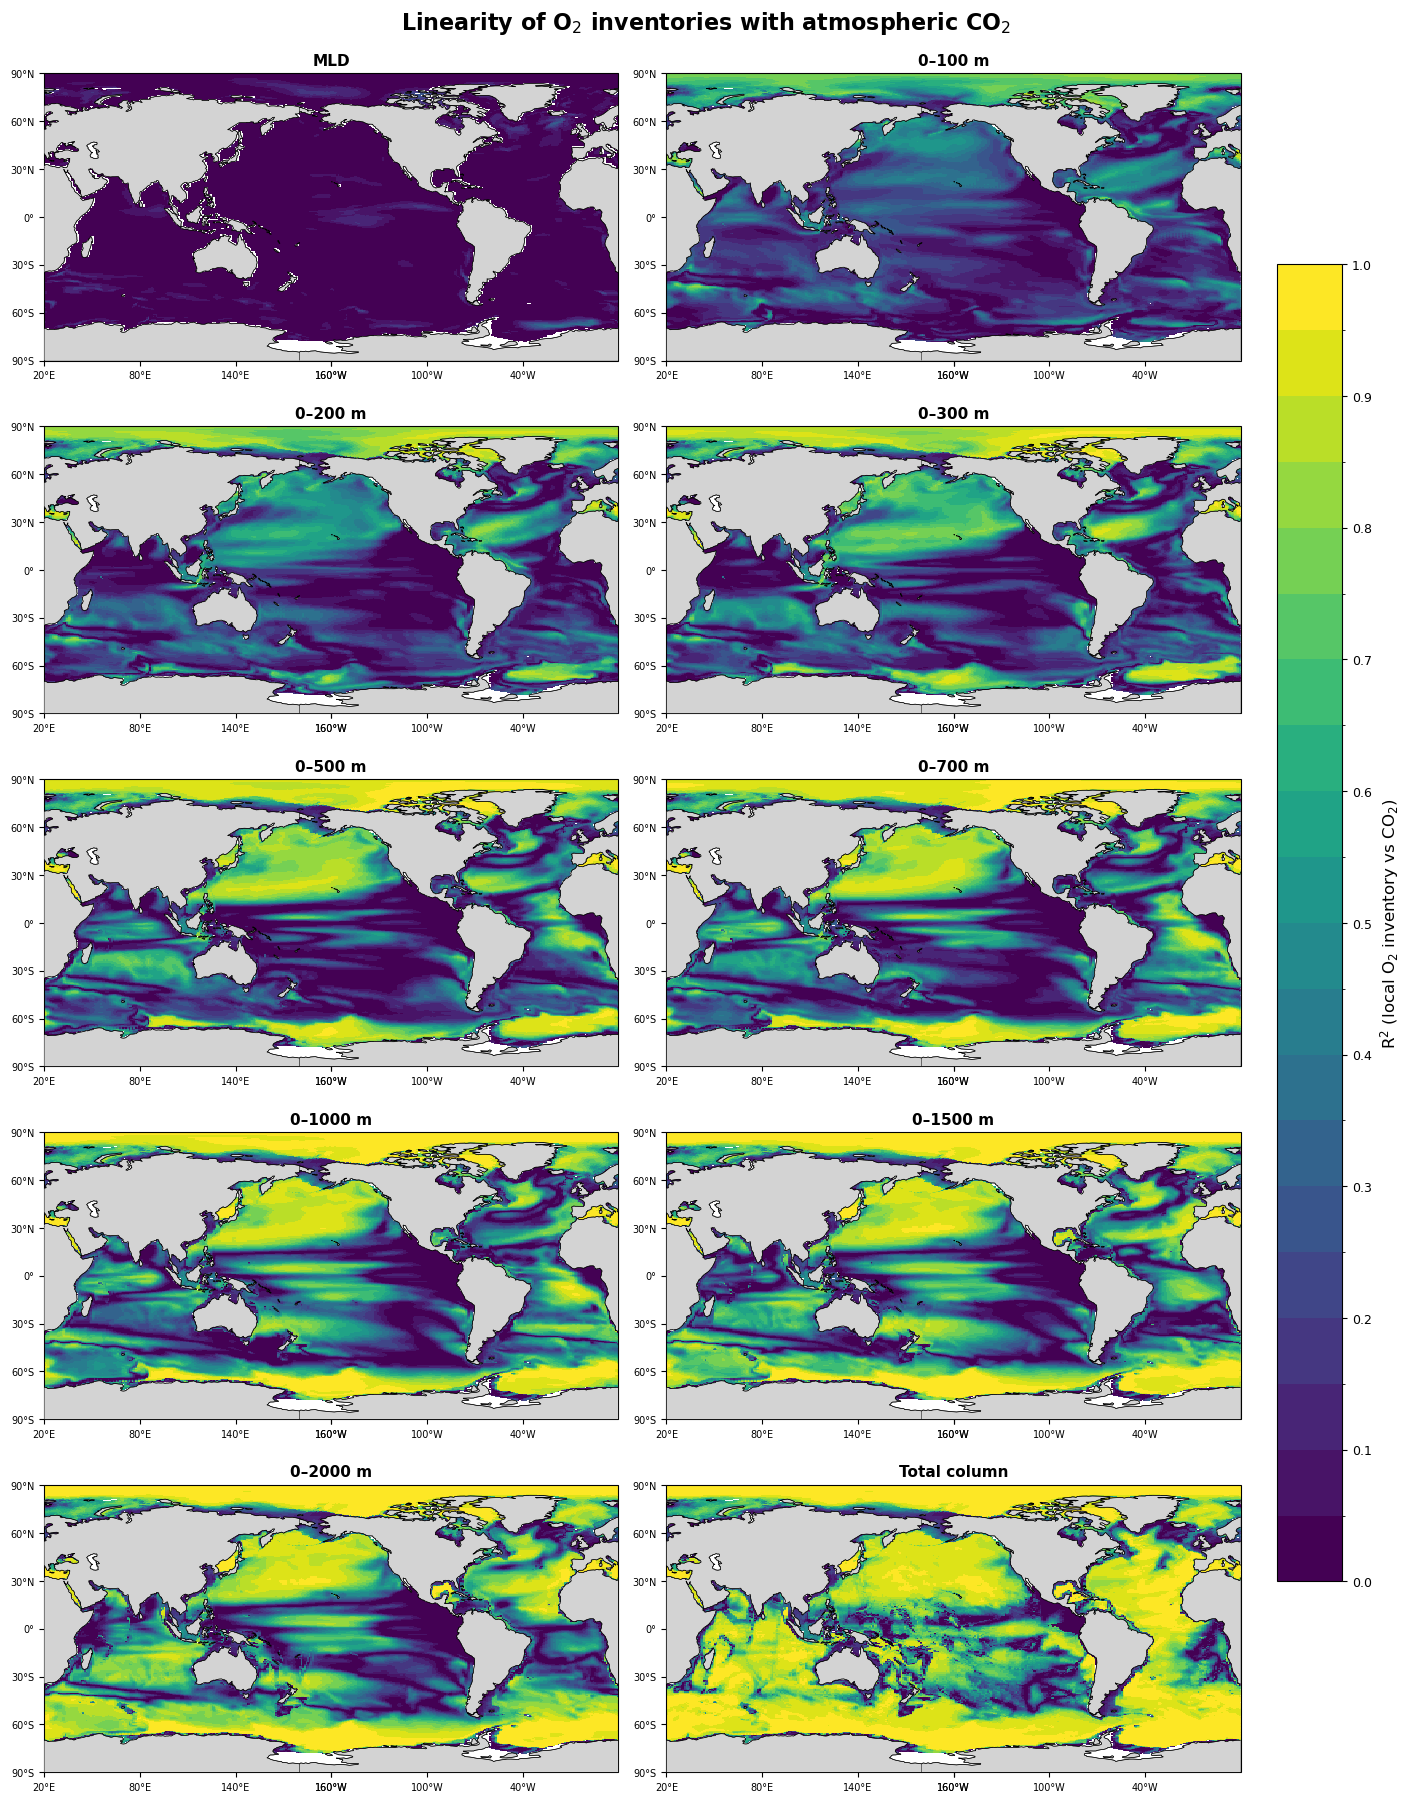

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import warnings

warnings.filterwarnings("ignore", message="The colormap's 'bad' has been set")

# ============================================================
# Colorbar
# ============================================================

levels = np.arange(0, 1.05, 0.05)

cmap = plt.get_cmap("viridis", len(levels) - 1).copy()
cmap.set_bad(alpha=0)

norm = mcolors.BoundaryNorm(levels, cmap.N)

# ============================================================
# Pretty variable labels
# ============================================================

label_map = {
    "o2_inv_mld": "MLD",
    "o2_inv_100m": "0–100 m",
    "o2_inv_200m": "0–200 m",
    "o2_inv_300m": "0–300 m",
    "o2_inv_500m": "0–500 m",
    "o2_inv_700m": "0–700 m",
    "o2_inv_1000m": "0–1000 m",
    "o2_inv_1500m": "0–1500 m",
    "o2_inv_2000m": "0–2000 m",
    "o2_inv_total": "Total column",
}

# ============================================================
# Map projection
# ============================================================

data_crs = ccrs.PlateCarree()
map_crs = ccrs.PlateCarree(central_longitude=200)

fig, axes = plt.subplots(
    5,
    2,
    figsize=(14, 18),
    subplot_kw={"projection": map_crs},
    constrained_layout=True
)

axes = axes.flatten()

for ax, (var, r2_map) in zip(axes, r2_maps_inv.items()):

    pcm = ax.pcolormesh(
        r2_map["longitude"],
        r2_map["latitude"],
        r2_map,
        transform=data_crs,
        cmap=cmap,
        norm=norm,
        shading="auto"
    )

    ax.add_feature(
        cfeature.LAND,
        facecolor="lightgray",
        edgecolor="black",
        linewidth=0.3,
        zorder=10
    )

    ax.coastlines(
        resolution="110m",
        linewidth=0.5,
        zorder=11
    )

    ax.set_global()

    ax.set_xticks(np.arange(-160, 201, 60), crs=data_crs)
    ax.set_yticks(np.arange(-90, 91, 30), crs=data_crs)

    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())

    ax.tick_params(labelsize=7)

    ax.set_title(
        label_map.get(var, var),
        fontsize=11,
        fontweight="bold"
    )

# Hide unused axes if any
for ax in axes[len(r2_maps_inv):]:
    ax.set_visible(False)

# ============================================================
# Colorbar
# ============================================================

cbar = fig.colorbar(
    pcm,
    ax=axes,
    boundaries=levels,
    ticks=np.arange(0, 1.1, 0.1),
    spacing="proportional",
    shrink=0.75,
    pad=0.03
)

cbar.set_label(
    "R$^2$ (local O$_2$ inventory vs CO$_2$)",
    fontsize=12
)

cbar.ax.tick_params(labelsize=9)

fig.suptitle(
    "Linearity of O$_2$ inventories with atmospheric CO$_2$",
    fontsize=16,
    fontweight="bold"
)

plt.savefig(
    "R2_O2_inventory_vs_CO2_panels_center200E.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()